# Song Analysis
This notebook will aim to solve these questions:
- How do differences in release strategies (Album_type: album, single, compilation) affect artist engagement performance?
- Does the distribution of audio features (Danceability, Energy, Loudness, etc.) differ significantly across different release formats (Album_type)?
- Which audio features (e.g., Tempo, Valence, Loudness) correlate most strongly with Spotify Streams and YouTube Views?

# Importing Data and Libraries

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [99]:
file_path = '/content/Spotify_Youtube.csv'
df = pd.read_csv(file_path)

In [100]:
df.head()

,Unnamed: 0,Artist,Url_spotify,Track,Album,Album_type,Uri,Danceability,Energy,Key,...,Url_youtube,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Stream
0,0,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Feel Good Inc.,Demon Days,album,spotify:track:0d28khcov6AiegSCpG5TuT,0.818,0.705,6.0,...,https://www.youtube.com/watch?v=HyHNuVaZJ-k,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221.0,6220896.0,169907.0,Official HD Video for Gorillaz' fantastic trac...,True,True,1.040235e+09
1,1,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Rhinestone Eyes,Plastic Beach,album,spotify:track:1foMv2HQwfQ2vntFf9HFeG,0.676,0.703,8.0,...,https://www.youtube.com/watch?v=yYDmaexVHic,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645.0,1079128.0,31003.0,The official video for Gorillaz - Rhinestone E...,True,True,3.100837e+08
2,2,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,spotify:track:64dLd6rVqDLtkXFYrEUHIU,0.695,0.923,1.0,...,https://www.youtube.com/watch?v=qJa-VFwPpYA,Gorillaz - New Gold ft. Tame Impala & Bootie B...,Gorillaz,8435055.0,282142.0,7399.0,Gorillaz - New Gold ft. Tame Impala & Bootie B...,True,True,6.306347e+07
3,3,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,On Melancholy Hill,Plastic Beach,album,spotify:track:0q6LuUqGLUiCPP1cbdwFs3,0.689,0.739,2.0,...,https://www.youtube.com/watch?v=04mfKJWDSzI,Gorillaz - On Melancholy Hill (Official Video),Gorillaz,211754952.0,1788577.0,55229.0,Follow Gorillaz online:\nhttp://gorillaz.com \...,True,True,4.346636e+08
4,4,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Clint Eastwood,Gorillaz,album,spotify:track:7yMiX7n9SBvadzox8T5jzT,0.663,0.694,10.0,...,https://www.youtube.com/watch?v=1V_xRb0x9aw,Gorillaz - Clint Eastwood (Official Video),Gorillaz,618480958.0,6197318.0,155930.0,The official music video for Gorillaz - Clint ...,True,True,6.172597e+08


## Data Handling

In [101]:
songs = df.drop(columns=['Unnamed: 0','Url_spotify','Uri','Url_youtube','Description']).copy()

**NOTE**: The choice is to choose only Licensed song

In [102]:
songs = songs[songs['Licensed'] == True]
songs = songs.drop(columns = 'Licensed')

In [103]:
for i in songs.columns:
    print("\nunique values in {}:\n".format(i),songs[i].unique())


unique values in Artist:
 ['Gorillaz' 'Red Hot Chili Peppers' '50 Cent' ... 'LE SSERAFIM' 'ThxSoMch'
 'SICK LEGEND']

unique values in Track:
 ['Feel Good Inc.' 'Rhinestone Eyes'
 'New Gold (feat. Tame Impala and Bootie Brown)' ...
 'OUTSIDE HARDSTYLE SPED UP' 'ONLY GIRL HARDSTYLE' 'MISS YOU HARDSTYLE']

unique values in Album:
 ['Demon Days' 'Plastic Beach'
 'New Gold (feat. Tame Impala and Bootie Brown)' ...
 'OUTSIDE HARDSTYLE SPED UP' 'ONLY GIRL HARDSTYLE' 'MISS YOU HARDSTYLE']

unique values in Album_type:
 ['album' 'single' 'compilation']

unique values in Danceability:
 [0.818  0.676  0.695  0.689  0.663  0.76   0.741  0.625  0.592  0.559
 0.618  0.595  0.458  0.427  0.556  0.451  0.666  0.7    0.902  0.614
 0.489  0.653  0.925  0.576  0.853  0.566  0.547  0.539  0.512  0.386
 0.624  0.425  0.429  0.486  0.371  0.617  0.557  0.545  0.449  0.491
 0.573  0.209  0.613  0.775  0.956  0.817  0.875  0.832  0.605  0.644
 0.496  0.623  0.687  0.492  0.554  0.529  0.524  0.58   0.585  0

**NOTE**: After selecting only Verified songs, official_videos now only have 1 variable - True.

In [104]:
songs = songs.drop(columns='official_video')

## Handling duplication

Method: Only dropping track that:
- All the characteristic of the song is similar

Since different song can have a same name:
- Tyler the Creator
- Charlie Puth

In [105]:
numeric_cols = songs[['Danceability', 'Energy', 'Loudness', 'Speechiness',
                     'Acousticness', 'Instrumentalness', 'Liveness',
                     'Valence', 'Tempo', 'Duration_ms']]
categorical_cols = songs[['Album_type','Key']]
song_popularity = songs[['Views','Stream','Comments','Likes']]
non_numeric_cols = songs[['Artist', 'Track', 'Album', 'Title', 'Channel']]

In [106]:
songs[numeric_cols.columns] = songs[numeric_cols.columns].astype('float64')
songs[categorical_cols.columns] = songs[categorical_cols.columns].astype('category')
songs[song_popularity.columns] = songs[song_popularity.columns].astype('float64')
songs[non_numeric_cols.columns] = songs[non_numeric_cols.columns].astype('string')

In [107]:
songs[songs.duplicated(subset=numeric_cols, keep=False)].sort_values(by=['Track','Album'])

In [109]:
artist_ana = songs.copy()

In [110]:
songs = songs.drop_duplicates(subset=numeric_cols, keep='first')
print(f"Dropping dup: {len(songs)}")
songs.info()

Dropping dup: 12943
<class 'pandas.core.frame.DataFrame'>
Index: 12943 entries, 0 to 20717
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Artist            12943 non-null  string  
 1   Track             12943 non-null  string  
 2   Album             12943 non-null  string  
 3   Album_type        12943 non-null  category
 4   Danceability      12942 non-null  float64 
 5   Energy            12942 non-null  float64 
 6   Key               12942 non-null  category
 7   Loudness          12942 non-null  float64 
 8   Speechiness       12942 non-null  float64 
 9   Acousticness      12942 non-null  float64 
 10  Instrumentalness  12942 non-null  float64 
 11  Liveness          12942 non-null  float64 
 12  Valence           12942 non-null  float64 
 13  Tempo             12942 non-null  float64 
 14  Duration_ms       12942 non-null  float64 
 15  Title             12943 non-null  string  
 16  Channel

## Null Handling

In [111]:
null_song = songs[songs[numeric_cols.columns].isnull().any(axis=1)]

**NOTE**: Only 1 song has null variable in song's characteristic
=> Drop that track would be the best choice in this situation

In [112]:
songs = songs.drop(null_song.index)

# Data Overview

## Song Overview

In [113]:
df.describe()

,Unnamed: 0,Danceability,Energy,Key,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_ms,Views,Likes,Comments,Stream
count,20718.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,2.071600e+04,2.024800e+04,2.017700e+04,2.014900e+04,2.014200e+04
mean,10358.500000,0.619777,0.635250,5.300348,-7.671680,0.096456,0.291535,0.055962,0.193521,0.529853,120.638340,2.247176e+05,9.393782e+07,6.633411e+05,2.751899e+04,1.359422e+08
std,5980.915774,0.165272,0.214147,3.576449,4.632749,0.111960,0.286299,0.193262,0.168531,0.245441,29.579018,1.247905e+05,2.746443e+08,1.789324e+06,1.932347e+05,2.441321e+08
min,0.000000,0.000000,0.000020,0.000000,-46.251000,0.000000,0.000001,0.000000,0.014500,0.000000,0.000000,3.098500e+04,0.000000e+00,0.000000e+00,0.000000e+00,6.574000e+03
25%,5179.250000,0.518000,0.507000,2.000000,-8.858000,0.035700,0.045200,0.000000,0.094100,0.339000,97.002000,1.800095e+05,1.826002e+06,2.158100e+04,5.090000e+02,1.767486e+07
50%,10358.500000,0.637000,0.666000,5.000000,-6.536000,0.050500,0.193000,0.000002,0.125000,0.537000,119.965000,2.132845e+05,1.450110e+07,1.244810e+05,3.277000e+03,4.968298e+07
75%,15537.750000,0.740250,0.798000,8.000000,-4.931000,0.103000,0.477250,0.000463,0.237000,0.726250,139.935000,2.524430e+05,7.039975e+07,5.221480e+05,1.436000e+04,1.383581e+08
max,20717.000000,0.975000,1.000000,11.000000,0.920000,0.964000,0.996000,1.000000,1.000000,0.993000,243.372000,4.676058e+06,8.079649e+09,5.078865e+07,1.608314e+07,3.386520e+09


In [114]:
spotify_info = songs[numeric_cols.columns.union(['Stream','Key'])]
youtube_info = songs[numeric_cols.columns.union(['Views','Likes','Comments','Key'])]

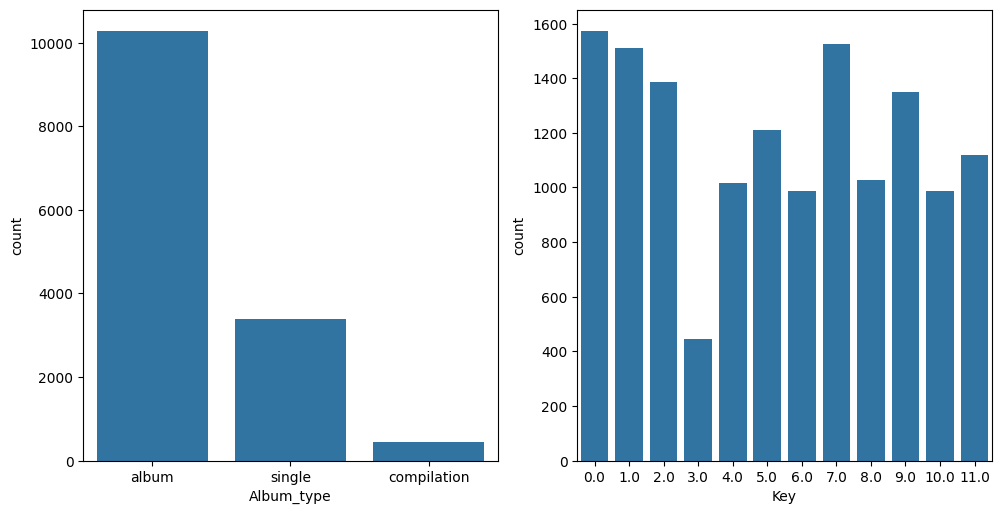

In [116]:
plt.figure(figsize = (20, 15))
plotnumber = 1

for column in categorical_cols.columns:
    if plotnumber <= 12:
        ax = plt.subplot(3, 4, plotnumber)
        sns.countplot(x=categorical_cols[column], ax=ax)
        plt.xlabel(column)

    plotnumber += 1

plt.tight_layout()

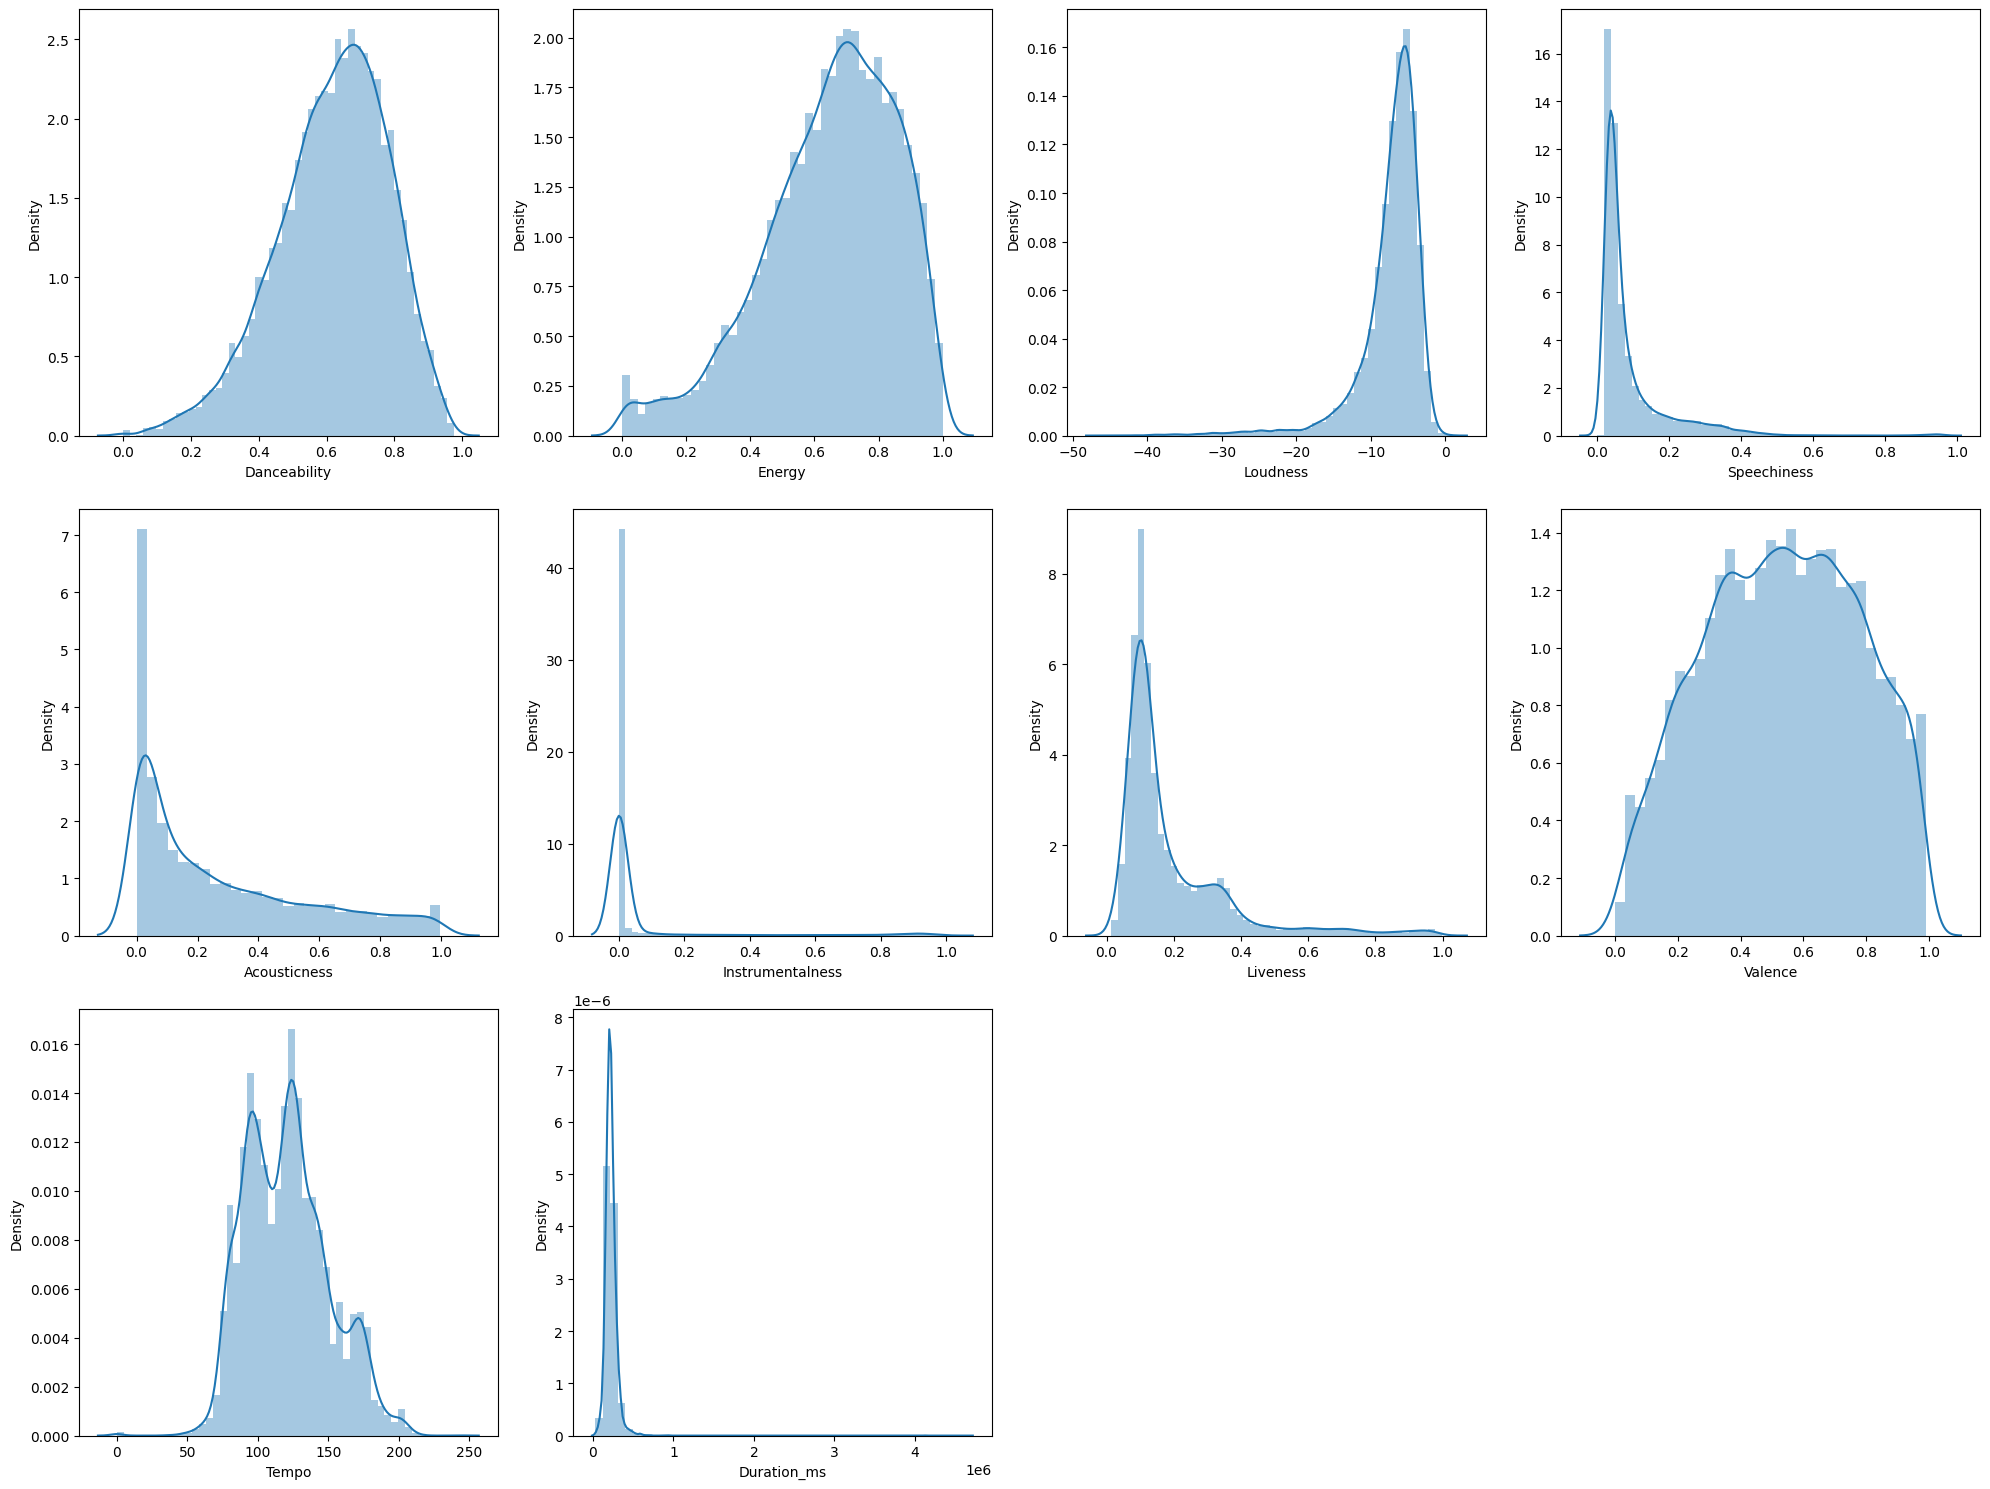

In [117]:
plt.figure(figsize = (20, 15))
plotnumber = 1

for column in numeric_cols.columns:
    if plotnumber <= 12:
        ax = plt.subplot(3, 4, plotnumber)
        sns.distplot(spotify_info[column])
        plt.xlabel(column)

    plotnumber += 1

plt.tight_layout()
plt.show()

**NOTE**: From the overview plot we can clearly see that:
- Right skewed: Speechiness, Acousticness, Instrumentalness, Liveness, Duration_ms
- Left skewed: Danceability, Energy, Loudness

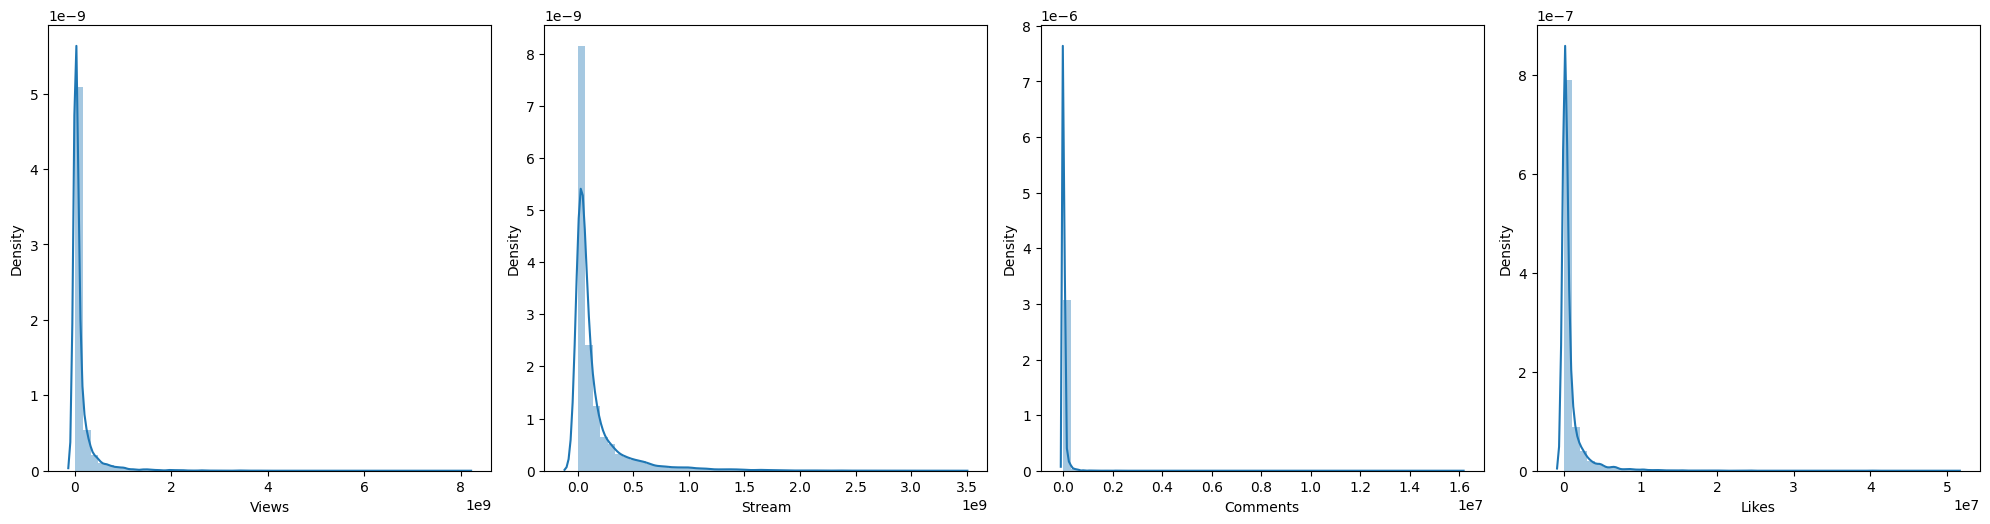

In [118]:
plt.figure(figsize = (20, 15))
plotnumber = 1

for column in song_popularity.columns:
    if plotnumber <= 12:
        ax = plt.subplot(3, 4, plotnumber)
        sns.distplot(song_popularity[column])
        plt.xlabel(column)

    plotnumber += 1

plt.tight_layout()

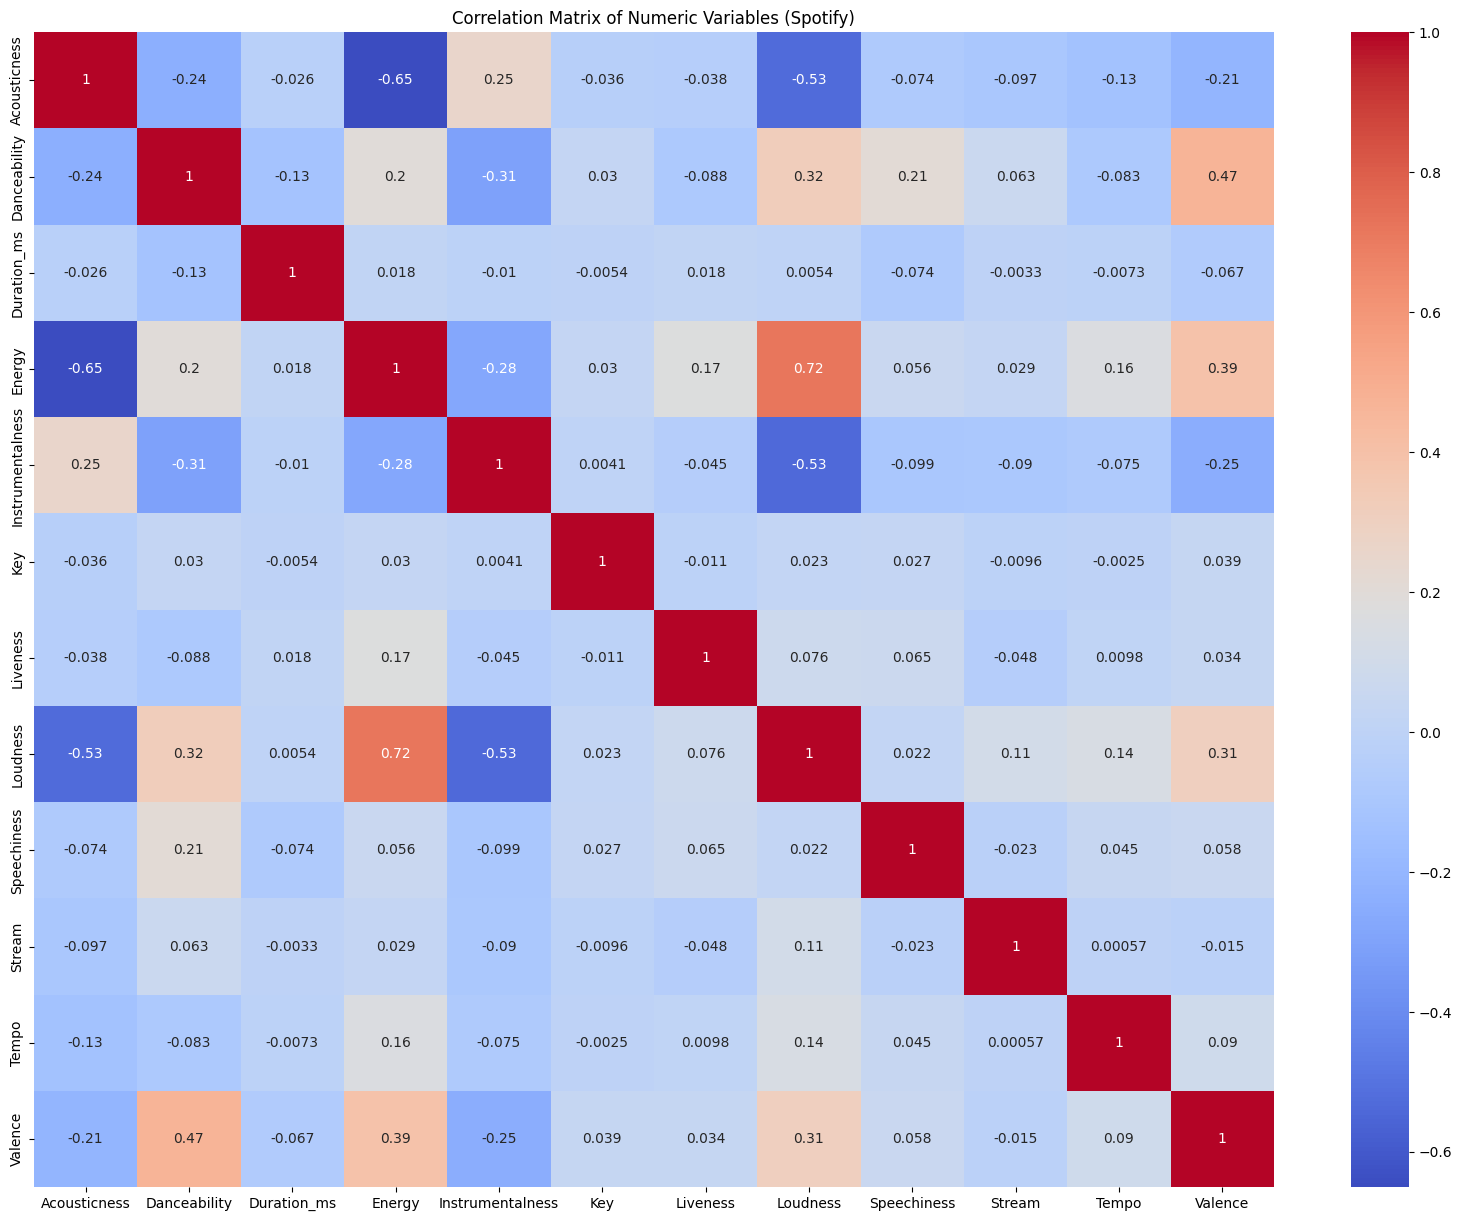

In [119]:
plt.figure(figsize=(20,15))
sns.heatmap(spotify_info.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numeric Variables (Spotify)')
plt.show()

**Note**: Based purely on the heatmap, we can tell that there is not a song characteristic that heavily impact on the number of Stream

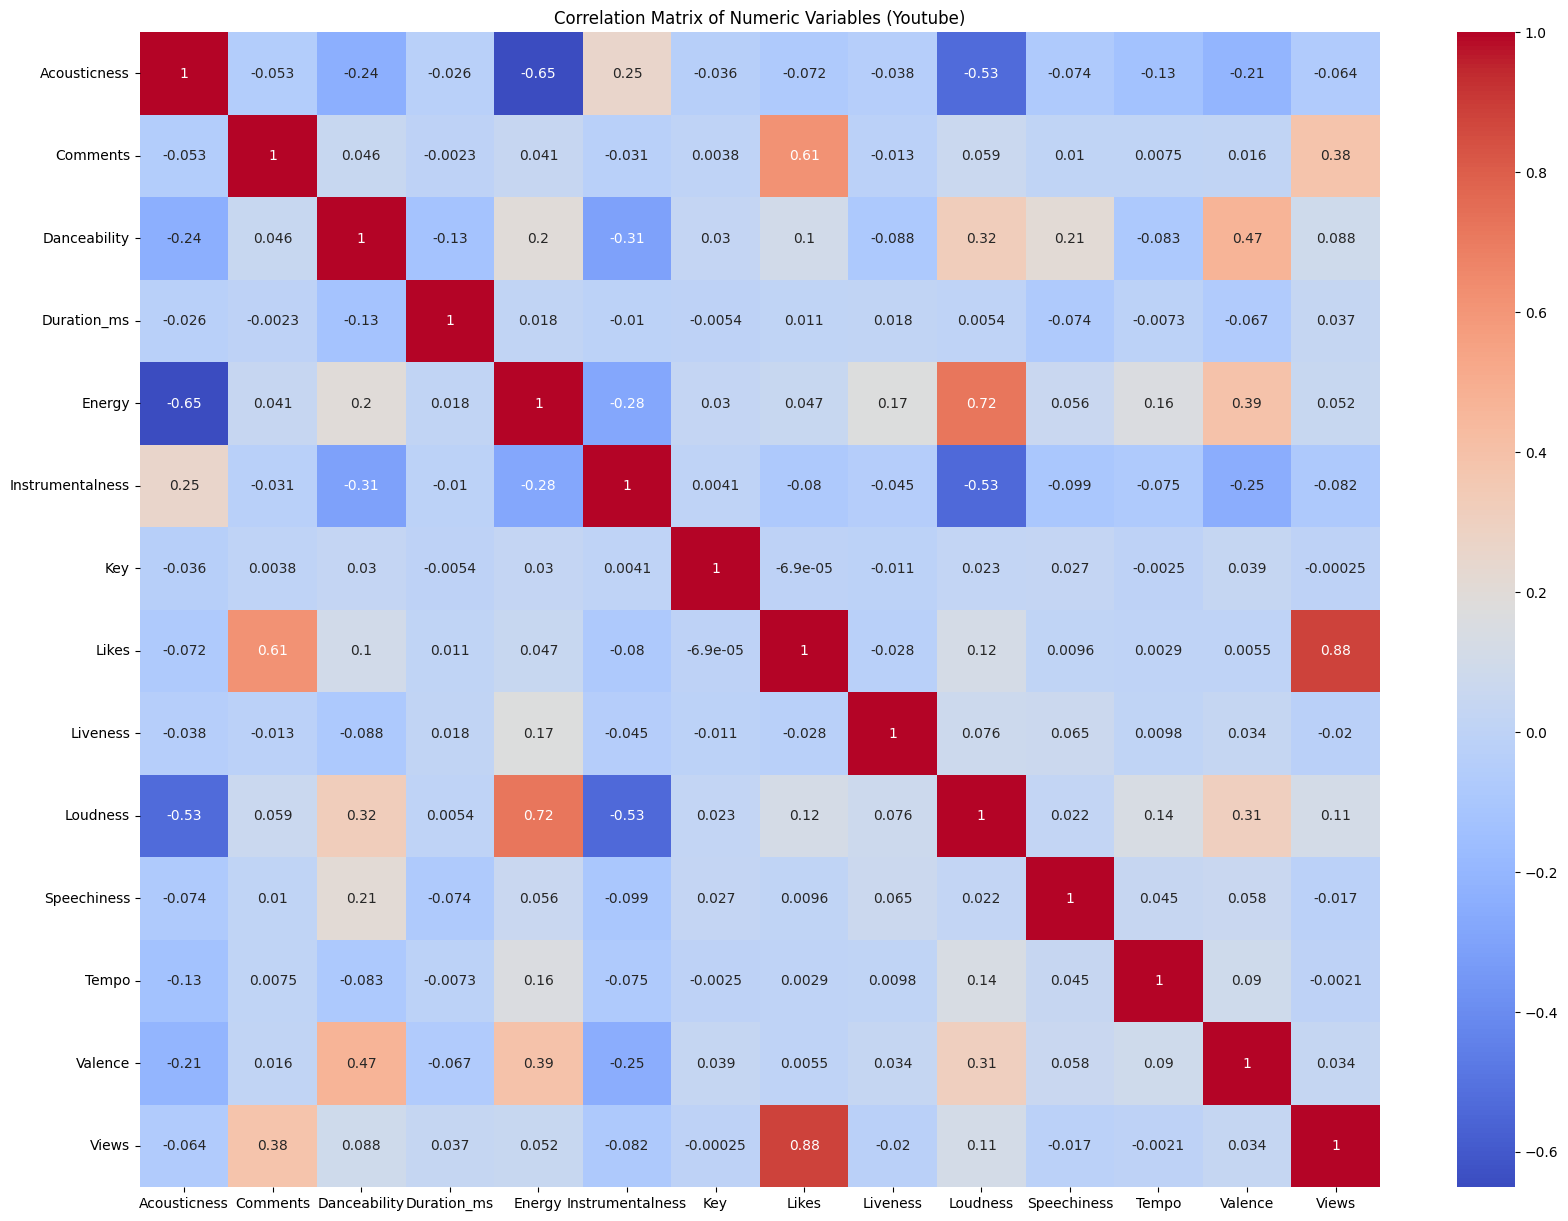

In [120]:
plt.figure(figsize=(20,15))
sns.heatmap(youtube_info.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numeric Variables (Youtube)')
plt.show()

**NOTE**: Similar to Spotify, there is no song characteristic heavily affect on the performance of a song.

**WHAT WE HAVE**: Based on the overview, we know that:
- There is no feature of a song that have a strong correlation with song popularity
- A lot of features seems to play a similar role => It is important to feature selection
- Most of the song is a part of an album => Might indicate that many songs might have quite relavant attribute

### Artist Album

In [121]:
album_groupby_artist = artist_ana.groupby('Artist')[['Album']].nunique().sort_values(by='Album', ascending=False).reset_index()
songs_groupby_artist = artist_ana.groupby('Artist')[['Track']].nunique().sort_values(by='Track', ascending=False).reset_index()
stream_groupby_artist = artist_ana.groupby('Artist')[['Stream']].sum().sort_values(by='Stream', ascending=False).reset_index()
view_groupby_artist = artist_ana.groupby('Artist')[['Views']].sum().sort_values(by='Views', ascending=False).reset_index()

In [128]:
artist_overall = pd.merge(album_groupby_artist, songs_groupby_artist, on='Artist')
artist_overall = pd.merge(artist_overall, stream_groupby_artist, on='Artist')
artist_overall = pd.merge(artist_overall, view_groupby_artist, on='Artist')
artist_overall['Avg_Stream'] = artist_overall['Stream'] / artist_overall['Track']
artist_overall['Avg_View'] = artist_overall['Views'] / artist_overall['Track']
artist_overall = artist_overall.sort_values(by='Stream', ascending=False)
artist_overall.head(10)

,Artist,Album,Track,Stream,Views,Avg_Stream,Avg_View
577,Ed Sheeran,6,10,1.439488e+10,1.546021e+10,1.439488e+09,1.546021e+09
1238,Post Malone,4,8,1.243216e+10,6.093324e+09,1.554020e+09,7.616655e+08
936,Dua Lipa,5,9,1.231142e+10,7.511817e+09,1.367936e+09,8.346463e+08
1399,Imagine Dragons,4,10,1.185831e+10,9.093785e+09,1.185831e+09,9.093785e+08
94,Coldplay,9,10,1.177848e+10,9.997278e+09,1.177848e+09,9.997278e+08
1095,The Weeknd,5,7,1.171657e+10,6.919935e+09,1.673795e+09,9.885622e+08
284,Ariana Grande,8,10,1.085741e+10,4.458246e+09,1.085741e+09,4.458246e+08
524,Billie Eilish,7,9,1.055823e+10,4.800023e+09,1.173136e+09,5.333359e+08
508,The Chainsmokers,7,10,1.039670e+10,5.442224e+09,1.039670e+09,5.442224e+08
1261,Bruno Mars,4,9,9.963335e+09,1.023184e+10,1.107037e+09,1.136871e+09


In [124]:
songs_groupby_artist[songs_groupby_artist['Artist'] == 'Kanye West']

,Artist,Track
489,Kanye West,9


In [129]:
artist_ana[artist_ana['Artist'] == 'Kanye West']

,Artist,Track,Album,Album_type,Danceability,Energy,Key,Loudness,Speechiness,Acousticness,...,Liveness,Valence,Tempo,Duration_ms,Title,Channel,Views,Likes,Comments,Stream
330,Kanye West,Bound 2,Yeezus,album,0.367,0.665,1.0,-2.821,0.0465,0.14500,...,0.1130,0.310,148.913,229147.0,Kanye West - Bound 2 (Explicit),KanyeWestVEVO,105206228.0,1105989.0,129255.0,5.781156e+08
331,Kanye West,Heartless,808s & Heartbreak,album,0.790,0.647,10.0,-5.983,0.1360,0.05150,...,0.2480,0.654,87.999,211000.0,Kanye West - Heartless,KanyeWestVEVO,200458945.0,1310078.0,63150.0,7.207564e+08
332,Kanye West,Flashing Lights,Graduation,album,0.639,0.628,6.0,-7.578,0.0399,0.03810,...,0.3860,0.430,90.482,237507.0,Kanye West - Flashing Lights ft. Dwele,KanyeWestVEVO,123256878.0,959510.0,35828.0,5.432864e+08
333,Kanye West,Ni**as In Paris,Watch The Throne (Deluxe),album,0.789,0.858,1.0,-5.542,0.3110,0.12700,...,0.3490,0.775,140.022,219333.0,Jay-Z & Kanye West - Ni**as In Paris (Explicit),KanyeWestVEVO,374189685.0,2521768.0,103200.0,1.054471e+09
334,Kanye West,Father Stretch My Hands Pt. 1,The Life Of Pablo,album,0.724,0.573,7.0,-4.113,0.0549,0.11800,...,0.5380,0.438,113.088,135920.0,Father Stretch My Hands Pt. 1,Kanye West - Topic,47207589.0,587832.0,6406.0,6.271673e+08
335,Kanye West,Stronger,Graduation,album,0.617,0.717,10.0,-7.858,0.1530,0.00564,...,0.4080,0.490,103.992,311867.0,Kanye West - Stronger,KanyeWestVEVO,432609094.0,2878369.0,156021.0,1.123296e+09
336,Kanye West,I Wonder,Graduation,album,0.542,0.466,0.0,-8.665,0.0831,0.14100,...,0.1250,0.124,191.385,243440.0,I Wonder,Kanye West - Topic,13652003.0,161439.0,692.0,3.028915e+08
338,Kanye West,Homecoming,Graduation,album,0.667,0.747,1.0,-7.059,0.1890,0.33700,...,0.1150,0.918,86.917,203493.0,Kanye West - Homecoming,KanyeWestVEVO,101552405.0,540229.0,25030.0,3.790999e+08
339,Kanye West,Gold Digger,Late Registration,album,0.629,0.696,1.0,-5.572,0.3480,0.01950,...,0.0554,0.623,93.034,207627.0,Kanye West - Gold Digger ft. Jamie Foxx,KanyeWestVEVO,323806093.0,1797312.0,71502.0,8.533815e+08


**NOTE**: Based on the previous finding, we are sure that dataset only contain track that does get uploaded to both Spotify and Youtube

=> So there is no point of analyze Album in general